# Weight Initialization

初始化决定了训练**能不能开始**。本课证明全零初始化的对称性陷阱，推导 Xavier 与 Kaiming 的方差公式，并可视化"激活方差随层数的传播"。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 全零初始化的对称性陷阱


如果所有权重初始为 0，同一层内所有神经元收到相同输入、产生相同输出、得到相同梯度——**永远无法打破对称**，网络退化为单神经元。

**证明**：$a_j = \sum_i w_{ji}x_i$，$w_{ji}=0 \Rightarrow a_j=0 \Rightarrow$ 所有 $j$ 的梯度 $\partial L/\partial w_{ji}$ 相同。


In [2]:
torch.manual_seed(0)
m = nn.Sequential(nn.Linear(2, 4), nn.Tanh(), nn.Linear(4, 1))
with torch.no_grad():
    for p in m.parameters():
        p.zero_()

x = torch.randn(8, 2); y = (x[:, 0] > 0).float().unsqueeze(1)
loss = F.binary_cross_entropy(torch.sigmoid(m(x)), y)
loss.backward()

print("隐藏层权重梯度（行 = 神经元）:")
print(m[0].weight.grad.numpy().round(4))
print("→ 4 行完全相同：4 个神经元永远学成同一个，白白浪费容量")


隐藏层权重梯度（行 = 神经元）:
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
→ 4 行完全相同：4 个神经元永远学成同一个，白白浪费容量


## 2. 方差传播与 Xavier 初始化


目标：让激活 $h = Wx$ 的**方差跨层不变**（避免逐层放大→爆炸 或 缩小→消失）。

设 $x$ 各分量独立、零均值、方差 $\mathrm{Var}[x]$，$W$ 各分量独立零均值方差 $\mathrm{Var}[W]$：

$$\mathrm{Var}[h_j] = \sum_{i=1}^{d_{in}} \mathrm{Var}[w_{ji} x_i] = d_{in}\,\mathrm{Var}[W]\,\mathrm{Var}[x]$$

要求 $\mathrm{Var}[h] = \mathrm{Var}[x]$ ⇒ $\mathrm{Var}[W] = \frac{1}{d_{in}}$（前向视角）。反向传播对称地要求 $\mathrm{Var}[W] = \frac{1}{d_{out}}$。**Xavier** 取两者调和：

$$\mathrm{Var}[W] = \frac{2}{d_{in} + d_{out}}$$


## 3. Kaiming（ReLU 修正）


ReLU 会把一半输入置零（负区），实际方差减半：$\mathrm{Var}[h] = \frac{d_{in}}{2}\mathrm{Var}[W]\mathrm{Var}[x]$。

要求方差守恒 ⇒ $$\mathrm{Var}[W] = \frac{2}{d_{in}}$$

tanh/sigmoid 用 Xavier，ReLU 用 Kaiming——**初始化要和激活函数匹配**。


plain: 激活标准差随层数指数衰减（梯度消失）
big  : 激活迅速饱和到 ±1（梯度消失的另一形态）
Xavier/Kaiming: 标准差稳定在 ~1（信号畅通）


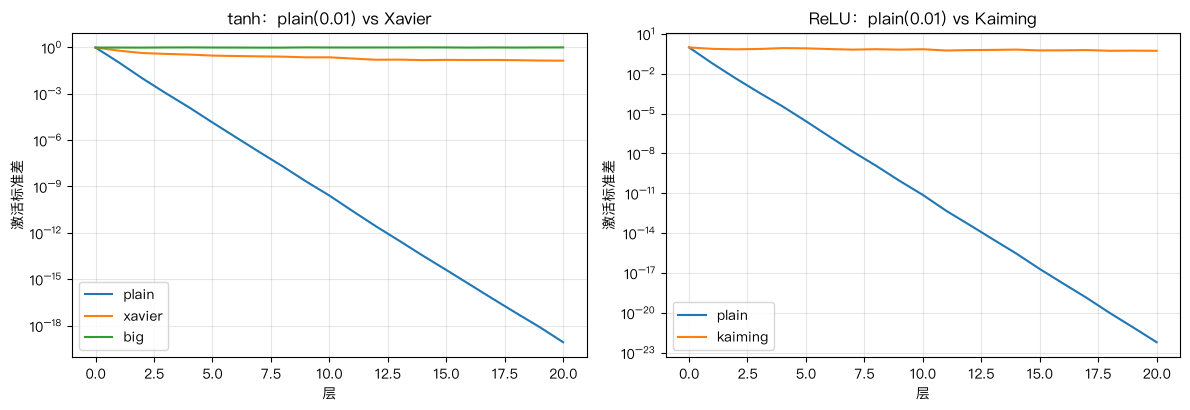

In [3]:
def activation_stds(depth, fan_in, init, activation, seed=0):
    r = np.random.default_rng(seed)
    x = r.standard_normal(fan_in)
    stds = [x.std()]
    for _ in range(depth):
        if init == 'plain':
            W = r.standard_normal((fan_in, fan_in)) * 0.01
        elif init == 'big':
            W = r.standard_normal((fan_in, fan_in)) * 1.0
        elif init == 'xavier':
            W = r.standard_normal((fan_in, fan_in)) * np.sqrt(2.0 / (2*fan_in))
        elif init == 'kaiming':
            W = r.standard_normal((fan_in, fan_in)) * np.sqrt(2.0 / fan_in)
        x = W @ x
        x = np.tanh(x) if activation == 'tanh' else np.maximum(0, x)
        stds.append(x.std())
    return np.array(stds)

L = 20; fin = 128
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for init, act, ax, title in [
    ('plain', 'tanh', axes[0], 'tanh：plain(0.01) vs Xavier'),
    ('xavier', 'tanh', axes[0], None),
    ('big', 'tanh', axes[0], None),
    ('plain', 'relu', axes[1], 'ReLU：plain(0.01) vs Kaiming'),
    ('kaiming', 'relu', axes[1], None),
]:
    s = activation_stds(L, fin, init, act)
    axes[0 if act == 'tanh' else 1].semilogy(s, label=init)
axes[0].set_title('tanh：plain(0.01) vs Xavier'); axes[1].set_title('ReLU：plain(0.01) vs Kaiming')
for ax in axes:
    ax.set_xlabel('层'); ax.set_ylabel('激活标准差'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
print("plain: 激活标准差随层数指数衰减（梯度消失）")
print("big  : 激活迅速饱和到 ±1（梯度消失的另一形态）")
print("Xavier/Kaiming: 标准差稳定在 ~1（信号畅通）")


## 4. 与梯度消失/爆炸的关联


激活方差失控 ⇒ 反向传播梯度也失控（链式法则连乘）：

$$\frac{\partial L}{\partial W^{(1)}} = \Big(\frac{\partial L}{\partial z^{(k)}} W^{(k)}\Big)\cdots\frac{\partial a^{(1)}}{\partial z^{(1)}}\,x$$

好的初始化把乘积控制在 ~1 附近。ResNet 的残差连接、BatchNorm 都是"让信号穿越深层"的补充手段（架构模块 02 课会验证残差的梯度效果）。


## 5. torch 的默认初始化


In [4]:
torch.manual_seed(0)
lin = nn.Linear(128, 128)
with torch.no_grad():
    w = lin.weight.numpy()
bound = np.sqrt(6.0 / ((1 + 5) * 128))      # PyTorch: kaiming_uniform(a=√5) 的边界
print(f"nn.Linear 默认: std = {w.std():.4f}，uniform 边界 = {bound:.4f}，理论 std = 边界/√3 = {bound/np.sqrt(3):.4f}")
print("→ PyTorch 默认用 Kaiming 均匀分布（a=√5），方差与推导一致")


nn.Linear 默认: std = 0.0511，uniform 边界 = 0.0884，理论 std = 边界/√3 = 0.0510
→ PyTorch 默认用 Kaiming 均匀分布（a=√5），方差与推导一致


## 课后练习


1. **推导**：写出 $\mathrm{Var}[h] = d_{in}\mathrm{Var}[W]\mathrm{Var}[x]$ 的完整步骤（用独立性 + 零均值）。
2. **数值验证**：用中心极限检验，$d_{in}=64$ 时 $h$ 是否接近高斯（画直方图）。
3. **实验**：Xavier 配 ReLU、Kaiming 配 tanh 分别训练，观察哪个更差，为什么。
4. **大 fan**：把 fan_in 从 128 改成 512，重跑方差传播，验证公式与层数无关。
5. **思考**：BatchNorm 出现后，初始化还重要吗？为什么？（提示：BN 重置尺度）
